## Thesis Chapter 3: Neural underpinnings of DD -- on sciencecloud

3. Individual brain map overlays: r2-nPRF vs DAN network (PFM)

Overlays two individual-specific maps on the cortical surface for a handful of example
subjects, both plotted in fsaverage5 space:
- **DAN network** (`nets_PFM/`, precision functional mapping, individual consensus
  parcellation, label 5 in the `caNets_DDnr` atlas) -- native fsLR 32k, resampled to
  fsaverage5 via `neuromaps.transforms.fslr_to_fsaverage`
- **nPRF R2** (`encoding_model.denoise/`) -- native fsaverage5, thresholded at `r2_threshold`

Sketch this is based on: `com_nPRF_pfm/comp_nPRF-22_pfm-DAN_01.ipynb`


In [16]:
import os.path as op
import os
import sys
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import nilearn.plotting as nplt 

sys.path.insert(0, '/home/ubuntu/git/parietal_patterns/nets_PFM')
from config import ATLAS_NETWORK_NAMES
from utils_01 import get_template_vertex_area, array_to_gifti

from parietal_patterns.utils.surfaces import get_basic_mask

from neuromaps import transforms

bids_folder = '/mnt_03/ds-dnumrisk'
group_df = pd.read_csv(op.join(bids_folder, 'group_assignment.csv')).set_index('subject')

BIDS_ROOT_LARGE = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk'
plot_folder = op.join(BIDS_ROOT_LARGE, 'thesis_materials', 'ind_brainMaps_overlays')
os.makedirs(plot_folder, exist_ok=True)

nPRF_folder = op.join(bids_folder, 'derivatives/encoding_model.denoise')
PFM_ROOT = op.join(bids_folder, 'derivatives/pfm_fslr')
NEUROMAPS_FSLR = '/home/ubuntu/neuromaps-data/atlases/fsLR'

ATLAS = 'caNets_DDnr' # 'gordon17' #
DAN_LABEL = 5
# network name for this label differs by atlas ('DorsAttn' vs 'Dorsal-attention') --
# check loosely instead of hardcoding one atlas's spelling
DAN_NAME = ATLAS_NETWORK_NAMES[ATLAS][DAN_LABEL]
assert 'att' in DAN_NAME.lower(), f"label {DAN_LABEL} in {ATLAS} is {DAN_NAME!r}, not dorsal-attention"

r2_threshold = 0.01 # nPRF R2 threshold for "significant" vertices -- may change later

# subjects to plot, one figure each (edit freely) -- subjects missing nPRF or PFM
# output are skipped with a printed warning (e.g. sub-03 has no nPRF data)
subList = [1]


In [10]:
# fsLR 32k medial-wall mask (same convention as nets_PFM/npc_net_ana.ipynb)
_, cortex_mask_L, cortex_mask_R = get_template_vertex_area(NEUROMAPS_FSLR)
cortex_mask_both = np.concatenate([cortex_mask_L, cortex_mask_R])  # (64984,)

# fsaverage5 cortex mask (Destrieux, excludes medial wall) -- blanks out non-cortex vertices
fsav5_cortex_mask, _ = get_basic_mask()  # (20484,) bool

def get_nPRF_r2_fsav5(sub_id):
    sub_str = f'sub-{sub_id:02d}'
    r2_L = nib.load(op.join(nPRF_folder, sub_str, 'ses-1', 'func',
                     f'{sub_str}_ses-1_desc-r2.optim.nilearn_space-fsaverage5_hemi-L.func.gii')).agg_data()
    r2_R = nib.load(op.join(nPRF_folder, sub_str, 'ses-1', 'func',
                     f'{sub_str}_ses-1_desc-r2.optim.nilearn_space-fsaverage5_hemi-R.func.gii')).agg_data()
    return np.concatenate([r2_L, r2_R])


Valid cortical nodes: L=29696, R=29716, total=59412
Total template cortical area: 178349 mm² (1783.5 cm²)


## Overalys

In [ ]:
def get_dan_mask_fsav5(sub_id, atlas=ATLAS, dan_label=DAN_LABEL):
    """Individual DAN network mask (PFM consensus, fsLR 32k) resampled to fsaverage5 (10k).

    Returns a boolean array (20484,), concatenated [L, R] -- same layout as the nPRF maps.
    """
    sub_str = f'sub-{sub_id:02d}'
    net_file = op.join(PFM_ROOT, sub_str, 'networks',
                        f'{sub_str}_ses-1_space-fsLR32k_consensus_ref-{atlas}_communities.npz')
    meta_file = op.join(PFM_ROOT, sub_str, 'cm',
                         f'{sub_str}_ses-1_space-fsLR32k_cm_meta.npz')

    labels = np.load(net_file)['network_labels']    # (n_valid,)
    valid_mask = np.load(meta_file)['valid_mask']    # (59412,) bool

    surf_cortex = np.zeros(cortex_mask_both.sum())
    surf_cortex[valid_mask] = labels
    full_fslr = np.zeros(64984)
    full_fslr[cortex_mask_both] = surf_cortex

    dan_L = (full_fslr[:32492] == dan_label).astype(float)
    dan_R = (full_fslr[32492:] == dan_label).astype(float)

    # nearest-neighbour resampling keeps the mask strictly binary (0/1)
    out_L, out_R = transforms.fslr_to_fsaverage(
        (array_to_gifti(dan_L), array_to_gifti(dan_R)), target_density='10k', method='nearest')
    dan_fsav5 = np.concatenate([out_L.agg_data(), out_R.agg_data()])
    return dan_fsav5.astype(bool)


def get_categorical_overlay(sub_id, r2_threshold=r2_threshold):
    """1 = DAN only, 2 = nPRF only, 3 = overlap. Everything else (incl. non-cortex) -> NaN.

    NaN vertices are left uncolored by nilearn -- they fall through to the plain
    sulcus-shaded bg_map, matching the untouched-cortex look in
    thesis_ch-DD-neuro_02_scloud.ipynb (where only the NPC mask carries values, the
    rest of the 20484-array stays NaN).
    """
    dan_mask = get_dan_mask_fsav5(sub_id)
    nprf_sig = get_nPRF_r2_fsav5(sub_id) > r2_threshold

    overlay = np.full(20484, np.nan)
    overlay[dan_mask & ~nprf_sig] = 1
    overlay[~dan_mask & nprf_sig] = 2
    overlay[dan_mask & nprf_sig] = 3
    overlay[~fsav5_cortex_mask] = np.nan
    return overlay


### Visualization: individual brain map overlays

In [18]:
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

dan_color = '#2CA02C'       # DAN only
nprf_color = '#D62728'      # nPRF R2 > threshold only
overlap_color = '#9467BD'   # both
# no "background" category/color: those vertices stay NaN and fall through to the
# plain sulcus-shaded bg_map (same as thesis_ch-DD-neuro_02_scloud.ipynb)

cmap_overlay = ListedColormap([dan_color, nprf_color, overlap_color])
vmin_overlay, vmax_overlay = 1, 3
darkness = 0.3   # matches thesis_ch-DD-neuro_02_scloud.ipynb

legend_handles = [
    mpatches.Patch(color=dan_color, label='DAN (PFM)'),
    mpatches.Patch(color=nprf_color, label=f'nPRF R² > {r2_threshold}'),
    mpatches.Patch(color=overlap_color, label='overlap'),
]


In [19]:
import io
from PIL import Image
from nilearn.datasets import fetch_surf_fsaverage
import nilearn.plotting as nplt
import matplotlib.pyplot as plt

fsaverage = fetch_surf_fsaverage('fsaverage5')

view_L = (30, 30 + (360 / 2))
view_R = (30, -30)

def render_surf_panel(surf_mesh, bg_map, surf_map_hemi, view):
    fig_panel = plt.figure(figsize=(4, 4))
    ax_panel = fig_panel.add_subplot(111, projection='3d')
    nplt.plot_surf(surf_mesh=surf_mesh, surf_map=surf_map_hemi, avg_method='median',
                    view=view, cmap=cmap_overlay, colorbar=False,
                    vmin=vmin_overlay, vmax=vmax_overlay, bg_map=bg_map, bg_on_data=True,
                    darkness=darkness, axes=ax_panel, figure=fig_panel)
    buf = io.BytesIO()
    fig_panel.savefig(buf, format='png', dpi=200, bbox_inches='tight', pad_inches=0)
    plt.close(fig_panel)
    buf.seek(0)
    img = Image.open(buf).convert('RGB')
    # auto-crop whitespace so panels pack tightly in the grid
    arr = np.array(img)
    nonwhite = np.any(arr < 250, axis=-1)
    r0, r1 = np.where(np.any(nonwhite, axis=1))[0][[0, -1]]
    c0, c1 = np.where(np.any(nonwhite, axis=0))[0][[0, -1]]
    pad = 5
    r0, c0 = max(r0 - pad, 0), max(c0 - pad, 0)
    r1, c1 = min(r1 + pad, arr.shape[0]), min(c1 + pad, arr.shape[1])
    return img.crop((c0, r0, c1, r1))

col_specs = [('L', fsaverage.infl_left, fsaverage.sulc_left, view_L),
             ('R', fsaverage.infl_right, fsaverage.sulc_right, view_R)]


Loop over `subList`, one separate figure per subject (L + R side by side), each saved
as its own PDF into `plot_folder`. Subjects missing nPRF or PFM output are skipped.

In [ ]:
for sub_id in subList:
    sub_str = f'sub-{sub_id:02d}'
    try:
        overlay = get_categorical_overlay(sub_id)
    except FileNotFoundError as e:
        print(f'{sub_str}: skipped ({e})')
        continue

    group = group_df.loc[sub_id, 'group'] if sub_id in group_df.index else np.nan
    group_label = 'DD' if group == 1 else ('TD' if group == 0 else 'n/a')

    panel_imgs = {}
    for hemi, surf_mesh_col, bg_map_col, view in col_specs:
        i_hemi = 0 if hemi == 'L' else 1
        surf_map_hemi = np.split(overlay, 2)[i_hemi]
        panel_imgs[hemi] = render_surf_panel(surf_mesh_col, bg_map_col, surf_map_hemi, view)

    fig, axes = plt.subplots(1, 2, figsize=(7, 3.7))
    for i_col, hemi in enumerate(['L', 'R']):
        axes[i_col].imshow(panel_imgs[hemi])
        axes[i_col].axis('off')

    fig.suptitle(f'{sub_str} ({group_label})', fontsize=13, y=0.98)
    fig.subplots_adjust(wspace=0.0, hspace=0.0, bottom=0.14, top=0.9, left=0.02, right=0.98)
    fig.legend(handles=legend_handles, loc='lower center', ncol=3, frameon=False,
               bbox_to_anchor=(0.5, 0.0))

    fig.savefig(op.join(plot_folder, f'{sub_str}_ch3_ind_nPRF-DAN_overlay_thresh-{r2_threshold}_atlas-{ATLAS}.pdf'),
                bbox_inches='tight')
    plt.show()


## Multi map visualizations

In [11]:
import glob
from utils_01 import get_CANets_cmap


def get_PFM_labels_fsav5(sub_id, atlas=ATLAS):
    """Individual whole-brain network labels (PFM consensus, fsLR 32k) resampled to
    fsaverage5 (10k). Returns integer labels (20484,), concatenated [L, R] -- same
    layout as the nPRF/gradient maps. 0 = unassigned.
    """
    sub_str = f'sub-{sub_id:02d}'
    net_file = op.join(PFM_ROOT, sub_str, 'networks',
                        f'{sub_str}_ses-1_space-fsLR32k_consensus_ref-{atlas}_communities.npz')
    meta_file = op.join(PFM_ROOT, sub_str, 'cm',
                         f'{sub_str}_ses-1_space-fsLR32k_cm_meta.npz')

    labels = np.load(net_file)['network_labels']    # (n_valid,)
    valid_mask = np.load(meta_file)['valid_mask']    # (59412,) bool

    surf_cortex = np.zeros(cortex_mask_both.sum())
    surf_cortex[valid_mask] = labels
    full_fslr = np.zeros(64984)
    full_fslr[cortex_mask_both] = surf_cortex

    # nearest-neighbour resampling keeps labels intact (no interpolation across networks)
    out_L, out_R = transforms.fslr_to_fsaverage(
        (array_to_gifti(full_fslr[:32492]), array_to_gifti(full_fslr[32492:])),
        target_density='10k', method='nearest')
    return np.concatenate([out_L.agg_data(), out_R.agg_data()])


GRADIENT_ROOT = op.join(BIDS_ROOT_LARGE, 'derivatives/gradients.tryParams.36P')

def get_gradients(sub_id, grad_N=2, alignRef='tanH',
                   specification='kernel-normalized_angle_ztransf-True'):
    sub = f'{sub_id:02d}'
    source_folder_gm = op.join(GRADIENT_ROOT, f'sub-{sub}')
    sub_file_pattern = op.join(source_folder_gm, f'sub-{sub}_g-aligned-{alignRef}_{specification}*.npy')
    fn = glob.glob(sub_file_pattern)[0]
    gm = np.load(fn)
    return gm[grad_N - 1, :]

In [22]:
def render_surf_panel(surf_mesh, bg_map, surf_map_hemi, view, cmap, vmin, vmax, darkness):
    fig_panel = plt.figure(figsize=(4, 4))
    ax_panel = fig_panel.add_subplot(111, projection='3d')
    nplt.plot_surf(surf_mesh=surf_mesh, surf_map=surf_map_hemi, avg_method='median',
                    view=view, cmap=cmap, colorbar=False,
                    vmin=vmin, vmax=vmax, bg_map=bg_map, bg_on_data=True,
                    darkness=darkness, axes=ax_panel, figure=fig_panel)
    buf = io.BytesIO()
    fig_panel.savefig(buf, format='png', dpi=200, bbox_inches='tight', pad_inches=0)
    plt.close(fig_panel)
    buf.seek(0)
    img = Image.open(buf).convert('RGB')
    # auto-crop whitespace so panels pack tightly in the grid
    arr = np.array(img)
    nonwhite = np.any(arr < 250, axis=-1)
    r0, r1 = np.where(np.any(nonwhite, axis=1))[0][[0, -1]]
    c0, c1 = np.where(np.any(nonwhite, axis=0))[0][[0, -1]]
    pad = 5
    r0, c0 = max(r0 - pad, 0), max(c0 - pad, 0)
    r1, c1 = min(r1 + pad, arr.shape[0]), min(c1 + pad, arr.shape[1])
    return img.crop((c0, r0, c1, r1))

In [28]:
sub_id = 46
r2_threshold = 0.02
grad_N = 2
group = group_df.loc[sub_id, 'group'] if sub_id in group_df.index else np.nan
group_label = 'DD' if group == 1 else ('TD' if group == 0 else 'n/a')

models = ['nPRF', 'grad', 'PFM']

pfm_labels = get_PFM_labels_fsav5(sub_id)
grad = get_gradients(sub_id, grad_N=grad_N)
r2 = get_nPRF_r2_fsav5(sub_id)
nprf_vals = np.where(r2 > r2_threshold, r2, np.nan)  # keep the R2 value where significant, NaN elsewhere


In [29]:
hemi_to_plot = 'R'   # single hemisphere for this multi-model, one-row-per-model grid
i_hemi = 0 if hemi_to_plot == 'L' else 1
surf_mesh_col, bg_map_col, view = (
    (fsaverage.infl_left, fsaverage.sulc_left, view_L) if hemi_to_plot == 'L'
    else (fsaverage.infl_right, fsaverage.sulc_right, view_R)
)

cmap_ca = get_CANets_cmap()
CANETS_VMAX = 12   # matches nets_PFM/05_plot.py REFS['caNets_DDnr']['vmax']

#grad_vlim = np.nanmax(np.abs(grad))   # symmetric around 0 -- gradient values are z-transformed
model_specs = {
    'nPRF': dict(data=nprf_vals,  cmap='turbo',    vmin=r2_threshold, vmax=np.nanmax(nprf_vals),
                 title=f'nPRF R² (> {r2_threshold})', darkness=darkness),
    'grad': dict(data=grad,       cmap='coolwarm', vmin=np.nanmin(grad),   vmax=np.nanmax(grad)      ,
                 title=f'Gradient {grad_N}', darkness=darkness),
    'PFM':  dict(data=pfm_labels, cmap=cmap_ca,    vmin=0,            vmax=CANETS_VMAX,
                 title=f'PFM networks ({ATLAS})', darkness=1),  # solid network colors hide the sulc shading more -- crank it up
}

In [31]:
print(np.nanmin(grad))
print(np.nanmax(grad))

-0.05170419584095792
0.1677108651524173


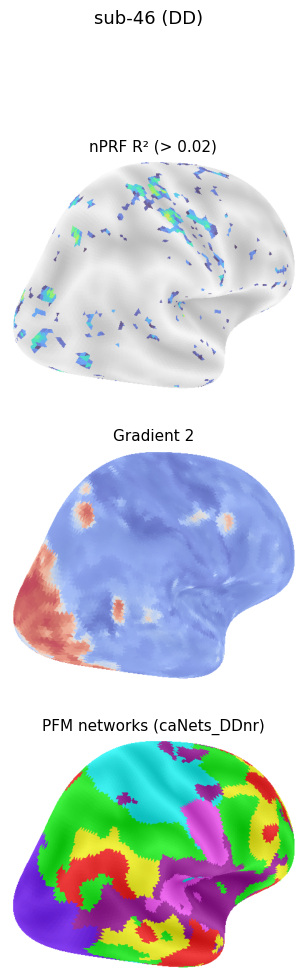

In [30]:
fig, axes = plt.subplots(len(models), 1, figsize=(3.7, 3.7 * len(models)))
for ax, model in zip(axes, models):
    spec = model_specs[model]
    surf_map_hemi = np.split(spec['data'], 2)[i_hemi]
    panel_img = render_surf_panel(surf_mesh_col, bg_map_col, surf_map_hemi, view,
                                   spec['cmap'], spec['vmin'], spec['vmax'], darkness=spec['darkness'])
    ax.imshow(panel_img)
    ax.axis('off')
    ax.set_title(spec['title'], fontsize=11)

fig.suptitle(f'sub-{sub_id:02d} ({group_label})', fontsize=13, y=0.995)
fig.subplots_adjust(hspace=0.05)
plt.show()